# Wine Quality Prediction

### Objective

The main goal of this dataset is to build predictive models that estimate the quality of wine based on its chemical properties.

### Importing Libraries

In [58]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns; sns.set_theme()

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.impute import SimpleImputer


from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score

from xgboost import  XGBRegressor


import warnings
warnings.filterwarnings('ignore')

### Importing and Reading Dataset

In [59]:
wine = pd.read_csv('../Dataset/winequalityN.csv')

wine.head()

,type,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,white,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6
1,white,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6
2,white,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6
3,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6
4,white,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6


### Summary Statistics

In [60]:
wine.describe()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,6487.000000,6489.000000,6494.000000,6495.000000,6495.000000,6497.000000,6497.000000,6497.000000,6488.000000,6493.000000,6497.000000,6497.000000
mean,7.216579,0.339691,0.318722,5.444326,0.056042,30.525319,115.744574,0.994697,3.218395,0.531215,10.491801,5.818378
std,1.296750,0.164649,0.145265,4.758125,0.035036,17.749400,56.521855,0.002999,0.160748,0.148814,1.192712,0.873255
min,3.800000,0.080000,0.000000,0.600000,0.009000,1.000000,6.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.400000,0.230000,0.250000,1.800000,0.038000,17.000000,77.000000,0.992340,3.110000,0.430000,9.500000,5.000000
50%,7.000000,0.290000,0.310000,3.000000,0.047000,29.000000,118.000000,0.994890,3.210000,0.510000,10.300000,6.000000
75%,7.700000,0.400000,0.390000,8.100000,0.065000,41.000000,156.000000,0.996990,3.320000,0.600000,11.300000,6.000000
max,15.900000,1.580000,1.660000,65.800000,0.611000,289.000000,440.000000,1.038980,4.010000,2.000000,14.900000,9.000000


### Checking For Missing Values

In [61]:
wine.isnull().sum().sort_values(ascending=False)

fixed acidity           10
pH                       9
volatile acidity         8
sulphates                4
citric acid              3
chlorides                2
residual sugar           2
type                     0
free sulfur dioxide      0
density                  0
total sulfur dioxide     0
alcohol                  0
quality                  0
dtype: int64

### Handling Missing Values

In [62]:
imputer = SimpleImputer(strategy='median')

missing_cols = ['fixed acidity', 'pH', 'volatile acidity', 'sulphates', 'citric acid', 'chlorides', 'residual sugar']

for cols in missing_cols:
    wine[cols] = imputer.fit_transform(wine[[cols]])

### Confirm Handling Missing Values 

In [63]:
wine.isnull().sum().sort_values(ascending=False)

type                    0
fixed acidity           0
volatile acidity        0
citric acid             0
residual sugar          0
chlorides               0
free sulfur dioxide     0
total sulfur dioxide    0
density                 0
pH                      0
sulphates               0
alcohol                 0
quality                 0
dtype: int64

### Handling Outliers

In [64]:
q1 = wine.select_dtypes(include=[np.number]).quantile(0.25)
q3 = wine.select_dtypes(include=[np.number]).quantile(0.75)

IQR = q3 - q1

lower_bound = q1 - 1.5 * IQR
upper_bound = q3 + 1.5 * IQR

print('Lower bound: \n', lower_bound)
print('Upper bound: \n', upper_bound)


Lower bound: 
 fixed acidity            4.450000
volatile acidity        -0.025000
citric acid              0.040000
residual sugar          -7.650000
chlorides               -0.002500
free sulfur dioxide    -19.000000
total sulfur dioxide   -41.500000
density                  0.985365
pH                       2.795000
sulphates                0.175000
alcohol                  6.800000
quality                  3.500000
dtype: float64
Upper bound: 
 fixed acidity             9.650000
volatile acidity          0.655000
citric acid               0.600000
residual sugar           17.550000
chlorides                 0.105500
free sulfur dioxide      77.000000
total sulfur dioxide    274.500000
density                   1.003965
pH                        3.635000
sulphates                 0.855000
alcohol                  14.000000
quality                   7.500000
dtype: float64


In [65]:
for col in wine.select_dtypes(include=[np.number]):
    mask = (wine[col] < lower_bound[col]) | (wine[col] > upper_bound[col])
    count = mask.sum()
    if count > 0:
        print(f'{col}: {count} outliers | '
              f'bounds=[{lower_bound[col]:.2f}, {upper_bound[col]:.2f}] | '
              f'actual min={wine[col].min():.2f}, max={wine[col].max():.2f}')


fixed acidity: 357 outliers | bounds=[4.45, 9.65] | actual min=3.80, max=15.90
volatile acidity: 376 outliers | bounds=[-0.02, 0.66] | actual min=0.08, max=1.58
citric acid: 508 outliers | bounds=[0.04, 0.60] | actual min=0.00, max=1.66
residual sugar: 118 outliers | bounds=[-7.65, 17.55] | actual min=0.60, max=65.80
chlorides: 286 outliers | bounds=[-0.00, 0.11] | actual min=0.01, max=0.61
free sulfur dioxide: 62 outliers | bounds=[-19.00, 77.00] | actual min=1.00, max=289.00
total sulfur dioxide: 10 outliers | bounds=[-41.50, 274.50] | actual min=6.00, max=440.00
density: 3 outliers | bounds=[0.99, 1.00] | actual min=0.99, max=1.04
pH: 73 outliers | bounds=[2.79, 3.63] | actual min=2.72, max=4.01
sulphates: 191 outliers | bounds=[0.17, 0.85] | actual min=0.22, max=2.00
alcohol: 3 outliers | bounds=[6.80, 14.00] | actual min=8.00, max=14.90
quality: 228 outliers | bounds=[3.50, 7.50] | actual min=3.00, max=9.00


### Visualizing the outliers

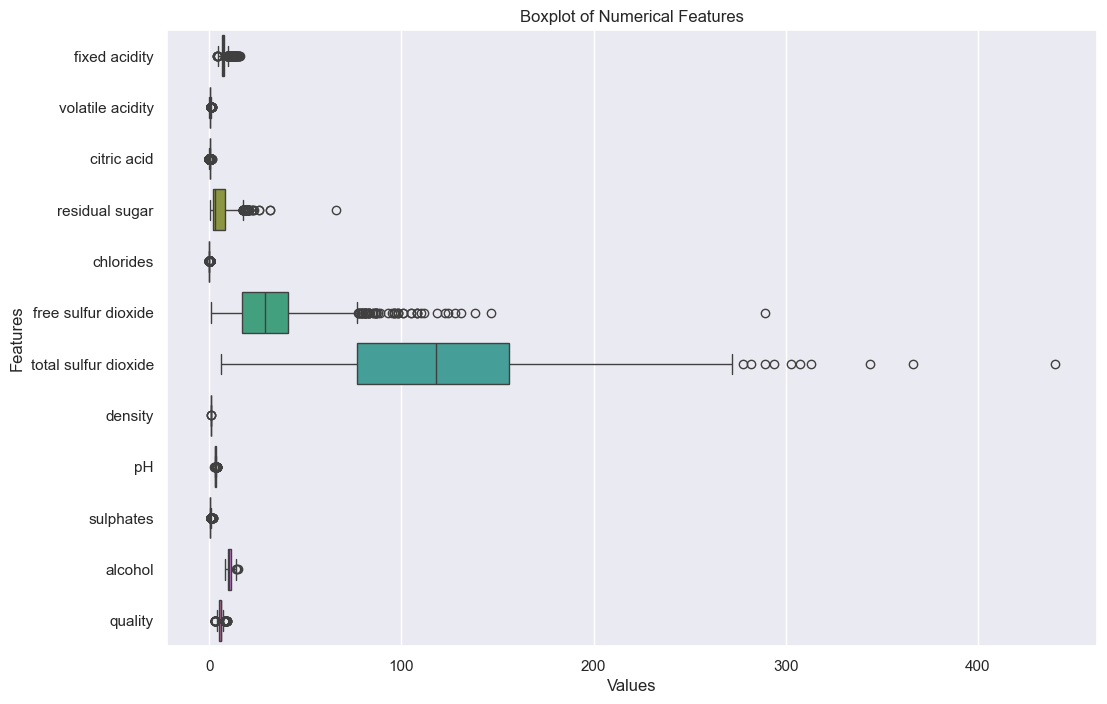

In [66]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=wine.select_dtypes(include=[np.number]), orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

###  `Winsorization` Replacing outliers with boundary values

In [67]:
for col in wine.select_dtypes(include=[np.number]):
    q1 = wine[col].quantile(0.25)
    q3 = wine[col].quantile(0.75)
    IQR = q3 -q1
    lower_bound = q1 - 1.5 * IQR
    upper_bound = q3 + 1.5 * IQR

    wine[col] = wine[col].clip(lower_bound, upper_bound)

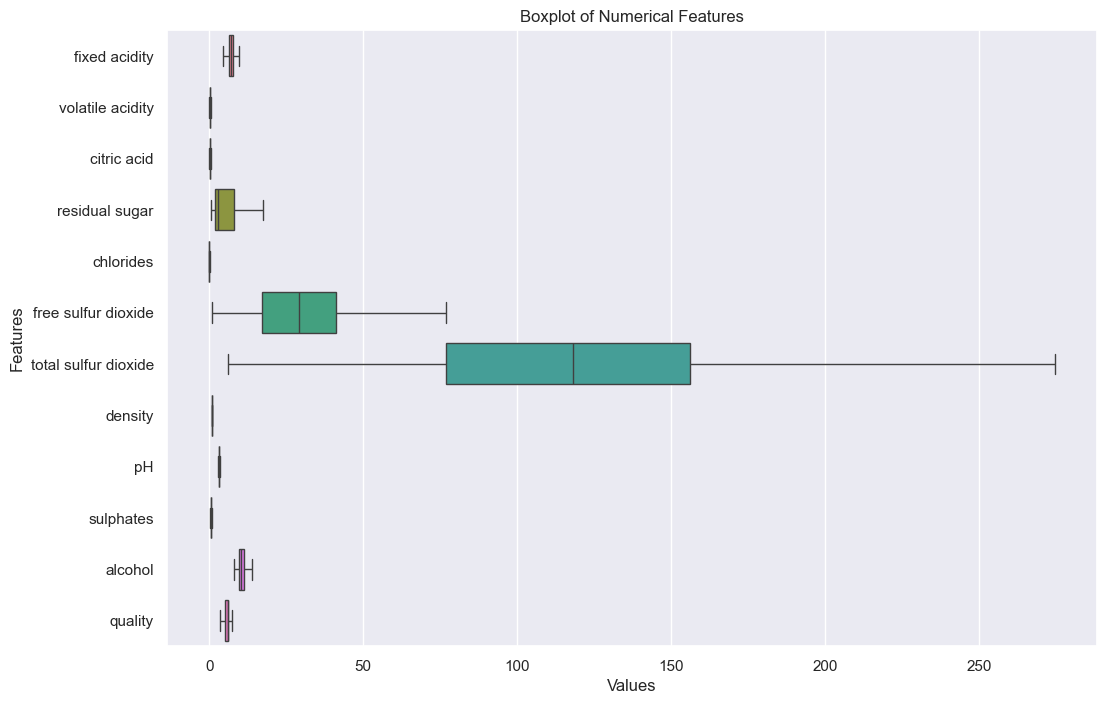

In [68]:
plt.figure(figsize=(12, 8))
sns.boxplot(data=wine.select_dtypes(include=[np.number]), orient='h')
plt.title('Boxplot of Numerical Features')
plt.xlabel('Values')
plt.ylabel('Features')
plt.show()

### Data Visualization

#### `Quality` by Wine type

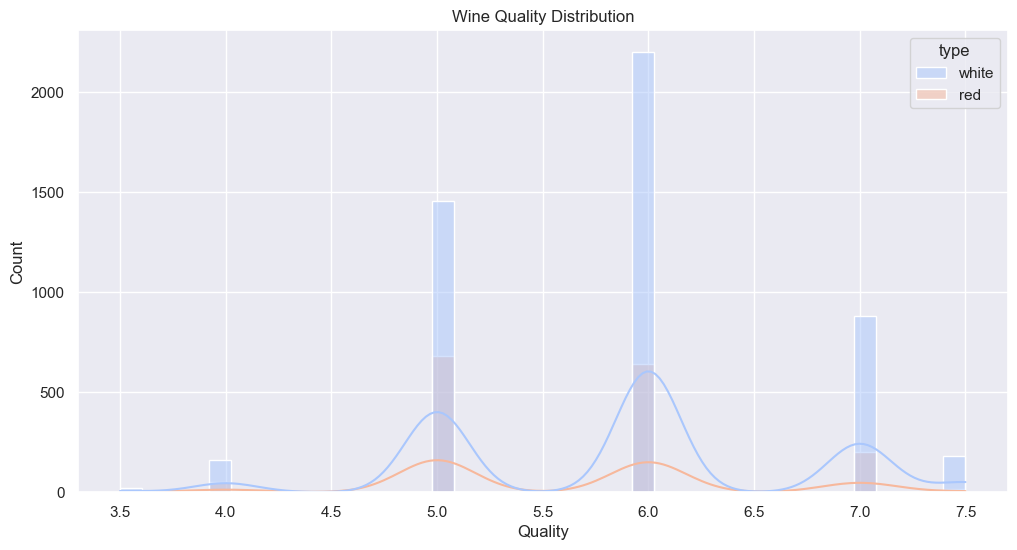

In [69]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'quality', kde=True, palette='coolwarm', hue='type')
plt.title('Wine Quality Distribution')
plt.xlabel('Quality')
plt.ylabel('Count')
plt.show()

#### `pH` Acidity Level by Wine type

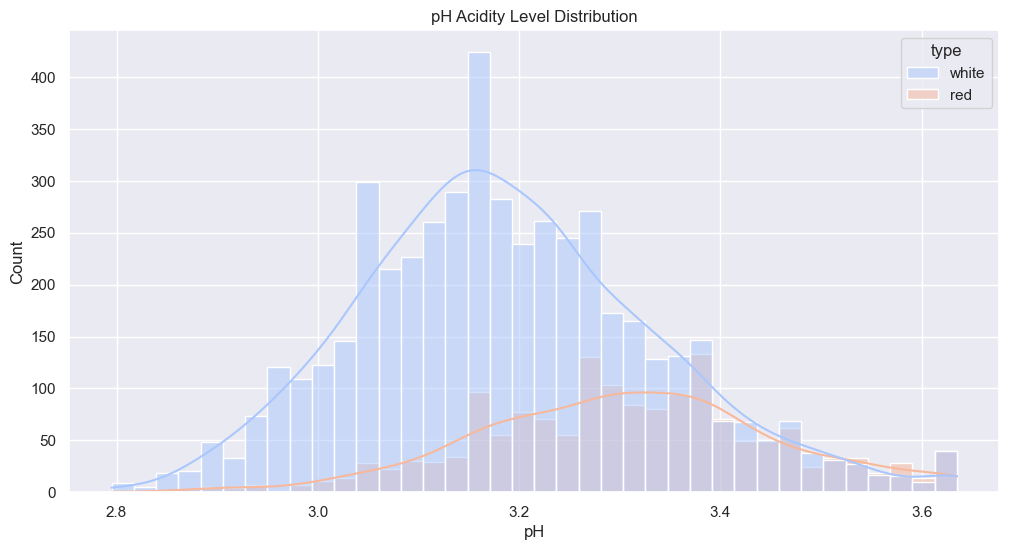

In [70]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'pH', kde=True, palette='coolwarm', hue='type')
plt.title('pH Acidity Level Distribution')
plt.xlabel('pH')
plt.ylabel('Count')
plt.show()

#### `Alcohol` Percentage by Wine type

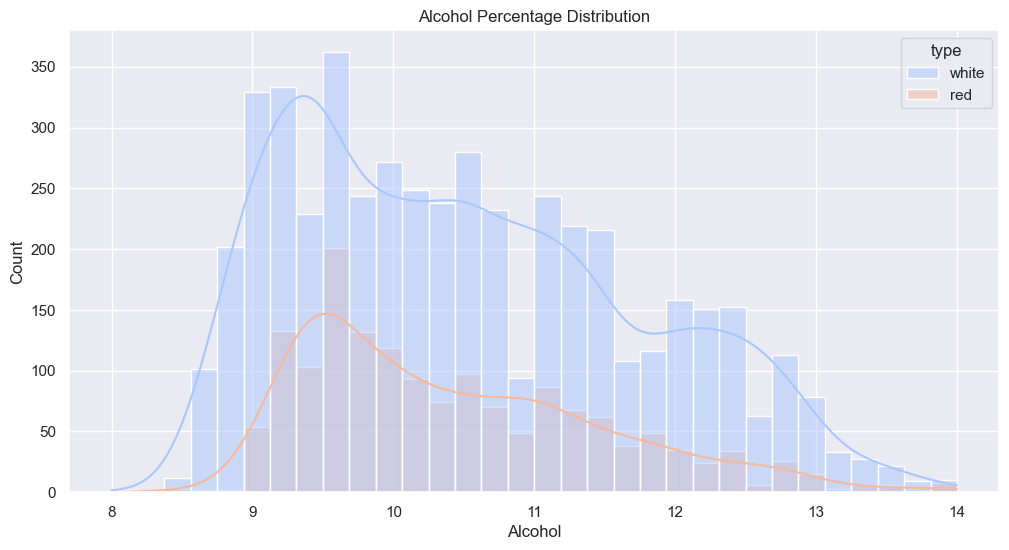

In [71]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'alcohol', kde=True, palette='coolwarm', hue='type')
plt.title('Alcohol Percentage Distribution')
plt.xlabel('Alcohol')
plt.ylabel('Count')
plt.show()

#### `Fixed Acidity` Level by Wine type

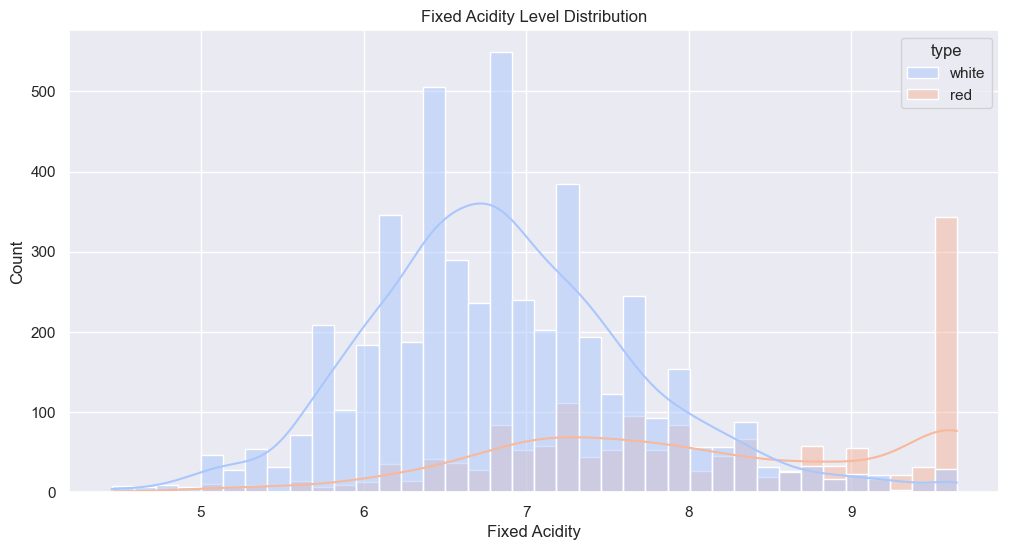

In [72]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'fixed acidity', kde=True, palette='coolwarm', hue='type')
plt.title('Fixed Acidity Level Distribution')
plt.xlabel('Fixed Acidity')
plt.ylabel('Count')
plt.show()

`Volatile Acidity` by Wine type

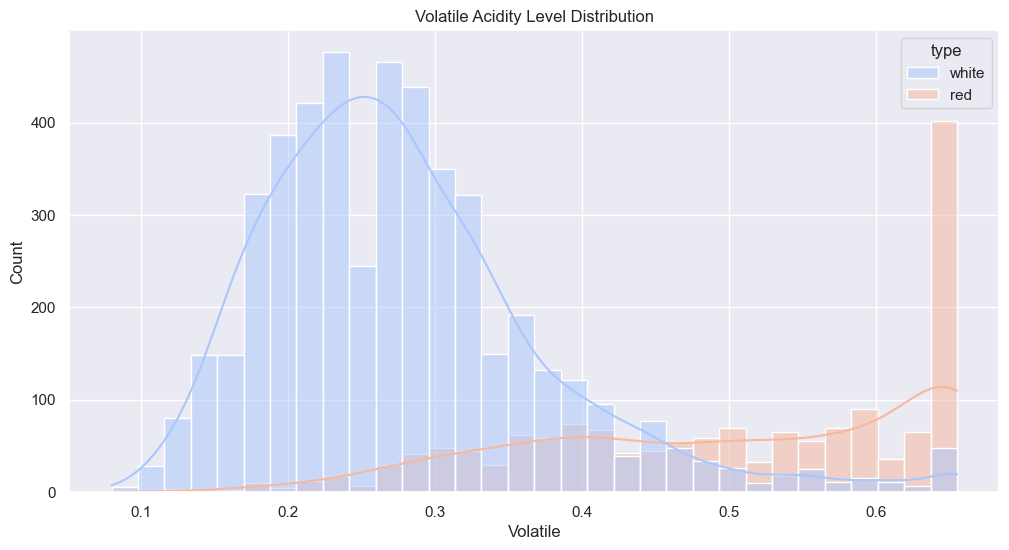

In [73]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'volatile acidity', kde=True, palette='coolwarm', hue='type')
plt.title('Volatile Acidity Level Distribution')
plt.xlabel('Volatile')
plt.ylabel('Count')
plt.show()

#### `Citric Acid` by wine type

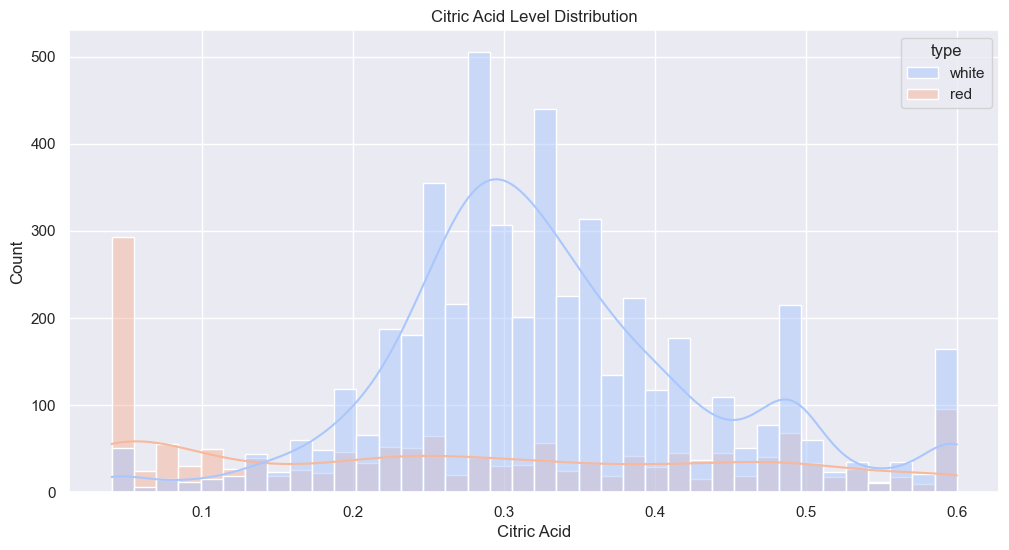

In [74]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'citric acid', kde=True, palette='coolwarm', hue='type')
plt.title('Citric Acid Level Distribution')
plt.xlabel('Citric Acid')
plt.ylabel('Count')
plt.show()

#### `Residual Sugar` Level by Wine type

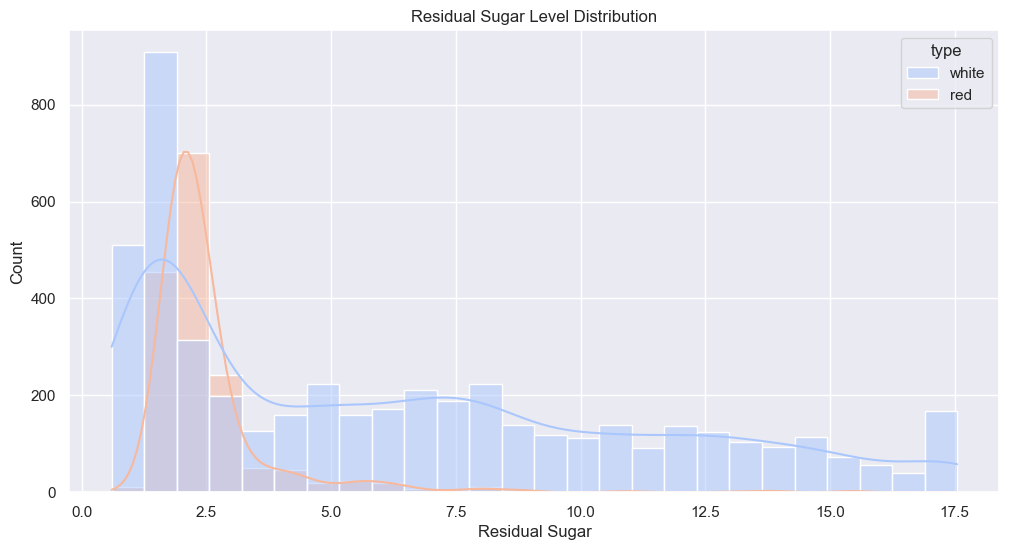

In [75]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'residual sugar', kde=True, palette='coolwarm', hue='type')
plt.title('Residual Sugar Level Distribution')
plt.xlabel('Residual Sugar')
plt.ylabel('Count')
plt.show()

#### `Chlorides` Level by Wine type

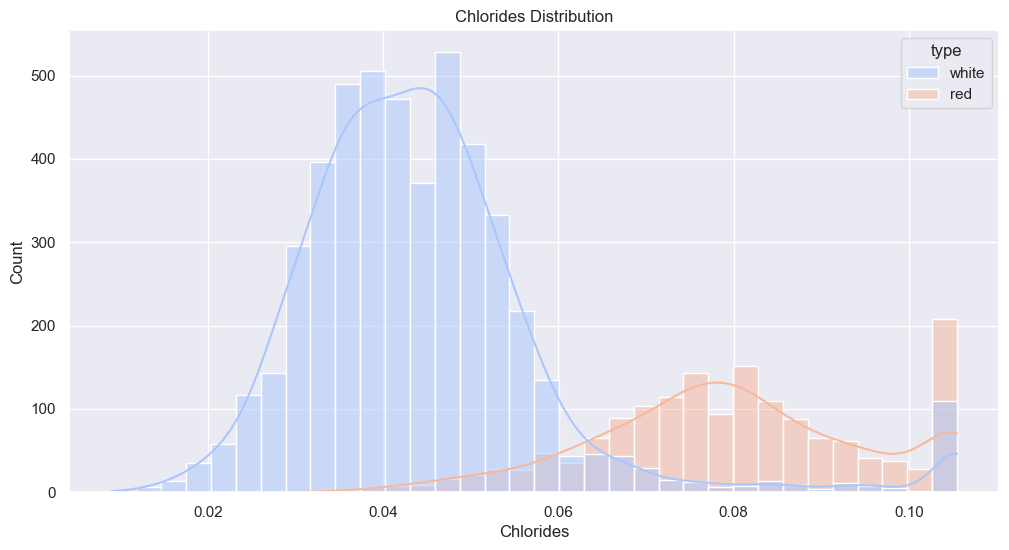

In [76]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'chlorides', kde=True, palette='coolwarm', hue='type')
plt.title('Chlorides Distribution')
plt.xlabel('Chlorides')
plt.ylabel('Count')
plt.show()

#### `Free Sulfur Dioxide` by Wine type

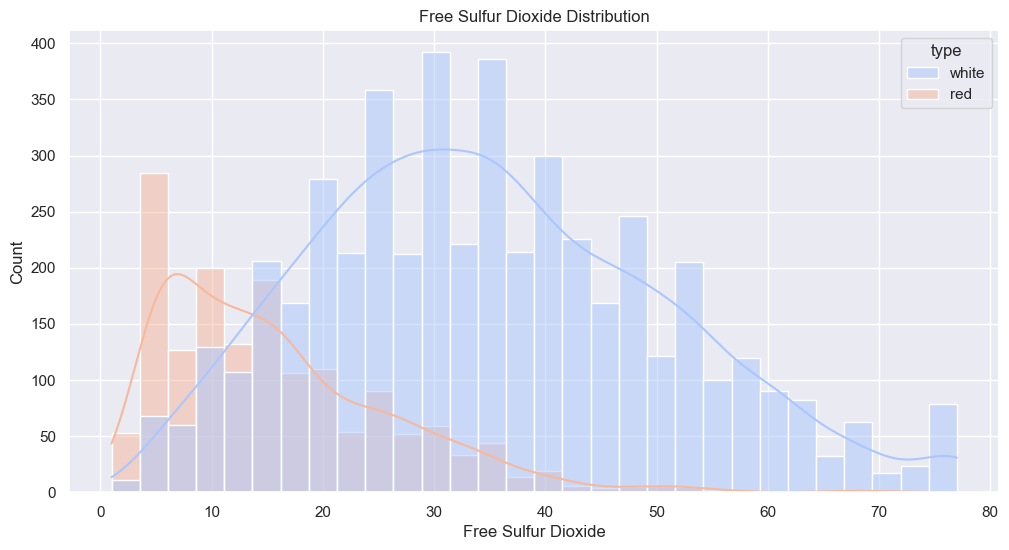

In [77]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'free sulfur dioxide', kde=True, palette='coolwarm', hue='type')
plt.title('Free Sulfur Dioxide Distribution')
plt.xlabel('Free Sulfur Dioxide')
plt.ylabel('Count')
plt.show()

#### `Total Sulfur Dioxide` by Wine type

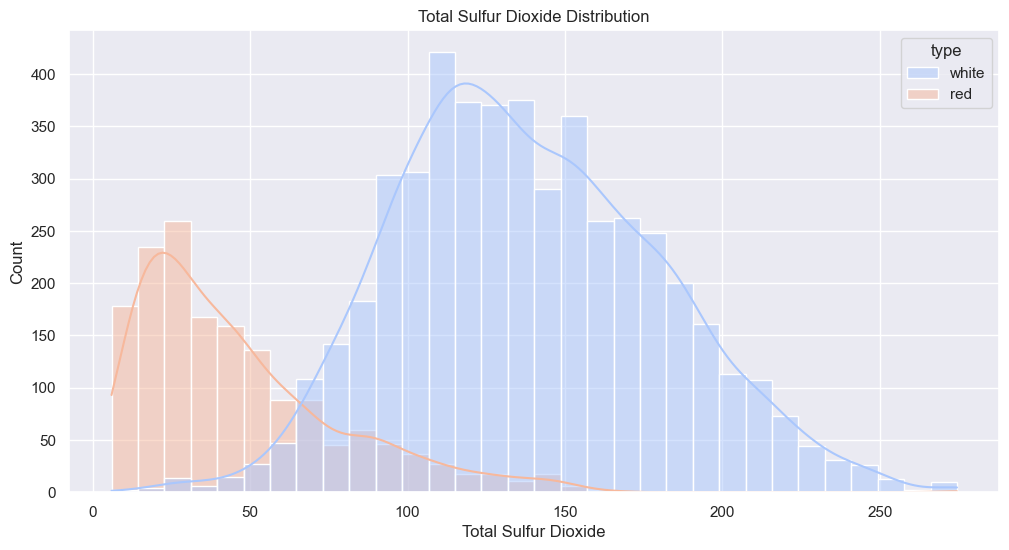

In [78]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'total sulfur dioxide', kde=True, palette='coolwarm', hue='type')
plt.title('Total Sulfur Dioxide Distribution')
plt.xlabel('Total Sulfur Dioxide')
plt.ylabel('Count')
plt.show()

#### `Sulphates` by Wine type

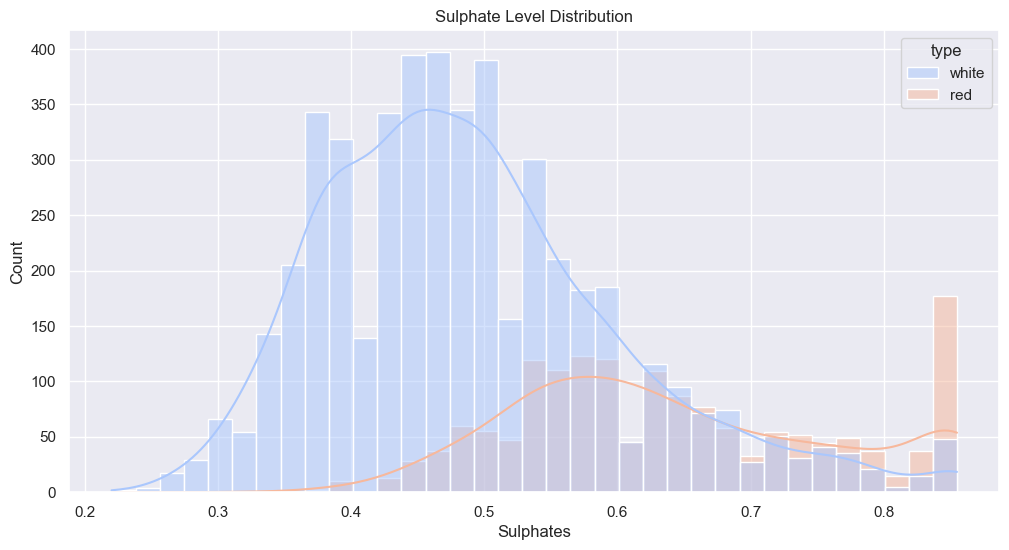

In [79]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'sulphates', kde=True, palette='coolwarm', hue='type')
plt.title('Sulphate Level Distribution')
plt.xlabel('Sulphates')
plt.ylabel('Count')
plt.show()

#### `Density` Level Distribution

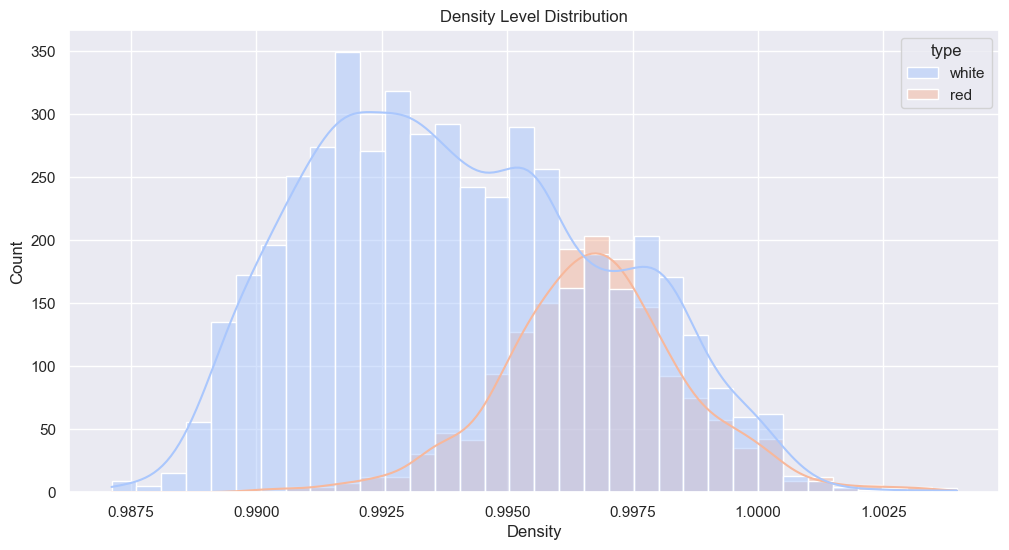

In [80]:
plt.figure(figsize=(12, 6))

sns.histplot(data=wine, x = 'density', kde=True, palette='coolwarm', hue='type')
plt.title('Density Level Distribution')
plt.xlabel('Density')
plt.ylabel('Count')
plt.show()

### Handling Categorical Column

Encoding wine `type` column using OneHotEncoder

In [81]:
wine = pd.get_dummies(wine, columns=['type'], dtype=int)

In [82]:
wine.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality,type_red,type_white
0,7.0,0.27,0.36,17.55,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,6.0,0,1
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,6.0,0,1
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,6.0,0,1
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6.0,0,1
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,6.0,0,1


#### `Correlation` Heatmap

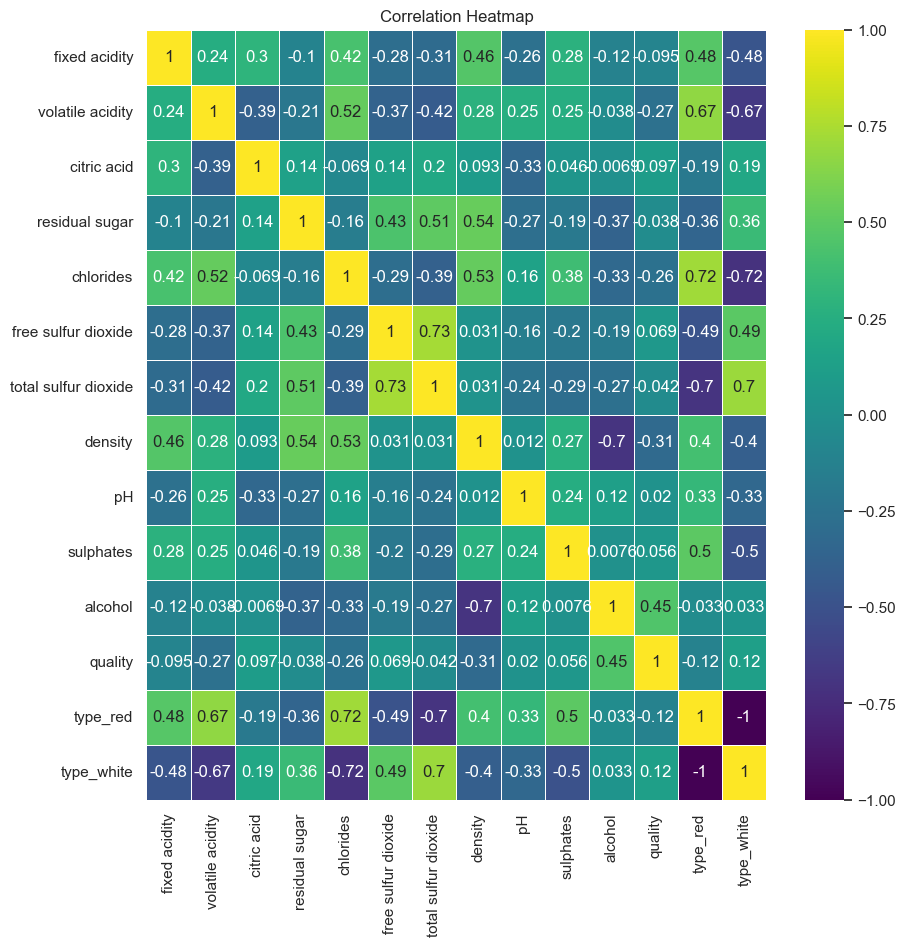

In [83]:
correlation = wine.corr()

plt.figure(figsize=(10, 10))
sns.heatmap(correlation, annot=True, cmap='viridis', linewidths=0.5)
plt.title('Correlation Heatmap')
plt.show()

### `Feature Selection and Data Splitting`

In [84]:
X = wine.drop(columns=['quality'], axis=1)
y = wine['quality']

In [85]:
X.head()

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,type_red,type_white
0,7.0,0.27,0.36,17.55,0.045,45.0,170.0,1.0010,3.00,0.45,8.8,0,1
1,6.3,0.30,0.34,1.60,0.049,14.0,132.0,0.9940,3.30,0.49,9.5,0,1
2,8.1,0.28,0.40,6.90,0.050,30.0,97.0,0.9951,3.26,0.44,10.1,0,1
3,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0,1
4,7.2,0.23,0.32,8.50,0.058,47.0,186.0,0.9956,3.19,0.40,9.9,0,1


In [86]:
y.head()

0    6.0
1    6.0
2    6.0
3    6.0
4    6.0
Name: quality, dtype: float64

### `Train Test Split`

In [87]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### `Model Training, Prediction and Evaluation`

### `Linear Regression`

Using `lr` within a pipeline for feature scaling 

In [88]:
pipe = Pipeline([
  ('scaler', StandardScaler()),
  ('model', LinearRegression())  
])

In [89]:
pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None


In [90]:
y_pred = pipe.predict(X_test)
print(y_pred)

[6.34048928 6.03797058 5.78328803 ... 5.66619178 5.64852807 5.42538285]


#### Evaluation and Cross Validation

In [91]:
print('Train Model Score: ', pipe.score(X_train, y_train))
print('Test Model Score: ', pipe.score(X_test, y_test))

Train Model Score:  0.2961175325947911
Test Model Score:  0.33948355930324403


In [92]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline Linear Regression: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline Linear Regression: MAE=0.53, RMSE=0.66, R2=0.34


In [93]:
pipe_cv_scores = cross_val_score(pipe, X, y, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
print(f'Pipeline CV RMSE:  {np.sqrt(-pipe_cv_scores).mean():.2f} +- {np.sqrt(-pipe_cv_scores).std():.2f}')

Pipeline CV RMSE:  0.71 +- 0.04


### `Lasso Regression`

In [94]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Lasso(random_state=42))
])

pipe.fit(X_train, y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: float, default=1.0Constant that multiplies the L1 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Lasso` object is not advised.Instead, you should use the :class:`LinearRegression` object.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"precompute precompute: bool or array-like of shape (n_features, n_features), default=FalseWhether to use a precomputed Gram matrix to speed upcalculations. The Gram matrix can also be passed as argument.For sparse input this option is always ``False`` to preserve sparsity.",False
,"copy_X copy_X: bool, default=TrueIf ``True``, X will be copied; else, it may be overwritten.",True


In [95]:
y_pred = pipe.predict(X_test)

y_pred

array([5.8035405, 5.8035405, 5.8035405, ..., 5.8035405, 5.8035405,
       5.8035405], shape=(1300,))

In [96]:
print('Train Model Score: ', pipe.score(X_train, y_train))
print('Test Model Score: ', pipe.score(X_test, y_test))

Train Model Score:  0.0
Test Model Score:  -4.8820897299739485e-05


#### Evaluation and Cross Validation

In [97]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline Lasso Regression: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline Lasso Regression: MAE=0.66, RMSE=0.81, R2=-0.00


In [98]:
pipe_cv_scores = cross_val_score(pipe, X, y, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
print(f'Pipeline CV RMSE:  {np.sqrt(-pipe_cv_scores).mean():.2f} +- {np.sqrt(-pipe_cv_scores).std():.2f}')

Pipeline CV RMSE:  0.83 +- 0.04


### `Ridge Regression`

In [99]:
pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', Ridge(random_state=42))
])

pipe.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"alpha alpha: {float, ndarray of shape (n_targets,)}, default=1.0Constant that multiplies the L2 term, controlling regularizationstrength. `alpha` must be a non-negative float i.e. in `[0, inf)`.When `alpha = 0`, the objective is equivalent to ordinary leastsquares, solved by the :class:`LinearRegression` object. For numericalreasons, using `alpha = 0` with the `Ridge` object is not advised.Instead, you should use the :class:`LinearRegression` object.If an array is passed, penalties are assumed to be specific to thetargets. Hence they must correspond in number.",1.0
,"fit_intercept fit_intercept: bool, default=TrueWhether to fit the intercept for this model. If setto false, no intercept will be used in calculations(i.e. ``X`` and ``y`` are expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"max_iter max_iter: int, default=NoneMaximum number of iterations for conjugate gradient solver.For 'sparse_cg' and 'lsqr' solvers, the default value is determinedby scipy.sparse.linalg. For 'sag' solver, the default value is 1000.For 'lbfgs' solver, the default value is 15000.",None


In [100]:
y_pred=pipe.predict(X_test)
print(y_pred)

[6.34029638 6.03785811 5.78324355 ... 5.66598259 5.64859875 5.42545669]


In [101]:
print('Train Model Score: ', pipe.score(X_train, y_train))
print('Test Model Score: ', pipe.score(X_test, y_test))

Train Model Score:  0.29611742222992654
Test Model Score:  0.33947381070903704


#### Evaluation and Cross validation

In [102]:
mae = mean_absolute_error(y_test, y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline Lasso Regression: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

Baseline Lasso Regression: MAE=0.53, RMSE=0.66, R2=0.34


In [103]:
pipe_cv_scores = cross_val_score(pipe, X, y, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
print(f'Pipeline CV RMSE:  {np.sqrt(-pipe_cv_scores).mean():.2f} +- {np.sqrt(-pipe_cv_scores).std():.2f}')

Pipeline CV RMSE:  0.71 +- 0.04


### `RandomForest Regressor`

In [104]:
rfr = RandomForestRegressor(random_state=42)
rfr.fit(X_train, y_train)

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [105]:
y_pred = rfr.predict(X_train)
print(y_pred)

[5.09  5.17  5.785 ... 5.9   6.96  6.915]


#### Evaluation and Cross Validation

In [106]:
print('Train Model Score: ', rfr.score(X_train, y_train))
print('Test Model Score: ', rfr.score(X_test, y_test))

Train Model Score:  0.9326562058807033
Test Model Score:  0.5591645239399525


In [107]:
y_pred = rfr.predict(X_test)
print(y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline RandomForest Regressor: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

[6.795 6.09  6.145 ... 5.235 5.85  5.89 ]
Baseline RandomForest Regressor: MAE=0.53, RMSE=0.54, R2=0.56


In [108]:
rfr_cv_scores = cross_val_score(rfr, X, y, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
print(f'RandomForest CV RMSE:  {np.sqrt(-rfr_cv_scores).mean():.2f} +- {np.sqrt(-rfr_cv_scores).std():.2f}')

RandomForest CV RMSE:  0.70 +- 0.06


#### `XGBRegressor`

In [114]:
xgb = XGBRegressor()

xgb.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_met

In [110]:
y_pred - xgb.predict(X_test)
print(y_pred)

[6.795 6.09  6.145 ... 5.235 5.85  5.89 ]


#### Evaluation and Cross Validation

In [111]:
print('Train Model Score: ', xgb.score(X_train, y_train))
print('Test Model Score: ', xgb.score(X_test, y_test))

Train Model Score:  0.9130863094109898
Test Model Score:  0.5046597922508494


In [112]:
y_pred = rfr.predict(X_test)
print(y_pred)
rmse = root_mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f'Baseline XGBRegressor: MAE={mae:.2f}, RMSE={rmse:.2f}, R2={r2:.2f}')

[6.795 6.09  6.145 ... 5.235 5.85  5.89 ]
Baseline XGBRegressor: MAE=0.53, RMSE=0.54, R2=0.56


In [113]:
xgb_cv_scores = cross_val_score(xgb, X, y, scoring='neg_mean_squared_error', n_jobs=-1, cv=5)
print(f'XGBRegressor CV RMSE:  {np.sqrt(-xgb_cv_scores).mean():.2f} +- {np.sqrt(-xgb_cv_scores).std():.2f}')

XGBRegressor CV RMSE:  0.74 +- 0.05
